In [1]:
#Import necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from statistics import *
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.backends.backend_pdf import PdfPages
import math
from scipy import stats
import sys
import copy
from collections import Counter
from collections import defaultdict
from datetime import datetime
from sklearn.ensemble import IsolationForest

In [2]:
def readData(patient):
    tm = pd.read_csv(f"{patient}_cleaned_removedays"'.csv')
    out = np.array(tm).tolist()  
    return out

In [3]:
patients=[1135, 1450, 1464, 1497, 1498, 1504, 1506, 1508, 1511, 1514, 1522, 1526, 1540, 1541, 1559, 1572, 1582, 1586, 1590, 1592, 1600, 1603, 1607, 1609, 1610, 1615, 1617, 1628, 1657, 1660, 1665, 1699, 1706, 1707, 1724]

In [4]:
def filter_training(patient,n_init):
    from datetime import datetime, timedelta
    import pandas as pd
    # Provided data
    data = readData(patient)
    # Convert to DataFrame
    df = pd.DataFrame(data, columns=['DateTime', 'Location'])
    # Convert the DateTime column to datetime objects
    df['DateTime'] = pd.to_datetime(df['DateTime'], format='%d/%m/%Y %H:%M:%S')

    # Extract the unique dates from the dataset
    unique_dates = df['DateTime'].dt.date.unique()
    # Sort the dates to find the earliest dates
    sorted_dates = sorted(unique_dates)
    # Select the first n days, if available
    first_n_days = sorted_dates[:n_init] if len(sorted_dates) >= n_init else sorted_dates
    # Filter the data to include only these dates
    data_first_n_days = df[df['DateTime'].dt.date.isin(first_n_days)]
    training_data = np.array(data_first_n_days).tolist() 
    
    # Convert Timestamps to string format as in the original data
    converted_data = [[timestamp.strftime('%d/%m/%Y %H:%M:%S'), location] 
                  for timestamp, location in training_data]
    
    return converted_data




In [5]:
def count_firings(data):
    import datetime
    hours=[i for i in range(0,24)]

    # 创建一个空字典，用于存储每天每小时的数据
    hour_counts = {}

    # 遍历每个数据点
    for d in data:
        # 将时间戳转换为日期和小时
        date = datetime.datetime.strptime(d[0].split(' ')[0], "%d/%m/%Y").date()
        hour = datetime.datetime.strptime(d[0].split(' ')[1], "%H:%M:%S").hour

        # 检查字典中是否已存在该日期和小时的数据
        if date not in hour_counts:
            hour_counts[date] = {}

        for h in hours:
            if h not in hour_counts[date]:
                if hour ==h:  
                    hour_counts[date][hour] = 0
                else:
                    hour_counts[date][h] = 0

        hour_counts[date][hour] += 1
        # 将数据点添加到字典中
    #     hourly_data[date][hour].append(value)
    return hour_counts

In [6]:
def hourly_firing(hour_counts_firings):
    # Initialize a dictionary with 24 keys, each containing an empty list to hold daily firings
    firings_per_hour_across_days = {hour: [] for hour in range(24)}

    # Populate the dictionary with firings data, including '-' for excluded hours
    for hour in range(24):
        for date in hour_counts_firings:
#             if (date, hour) in left_set or (date, hour) in visitor_set:
#                 # Mark as '-' for this specific hour on this date
#                 firings_per_hour_across_days[hour].append('-')
#             else:
            # Add the firing count for this hour on this date
            firings_per_hour_across_days[hour].append(hour_counts_firings[date].get(hour, 0))
    return firings_per_hour_across_days            

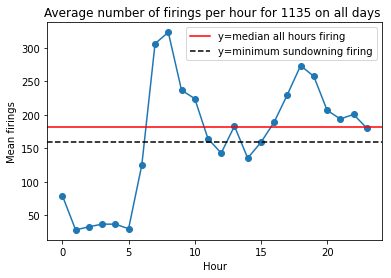

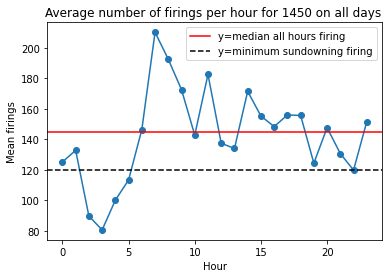

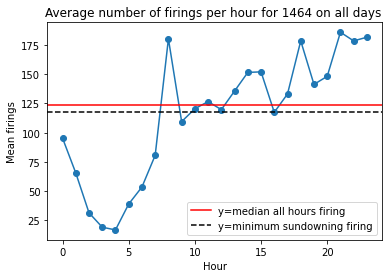

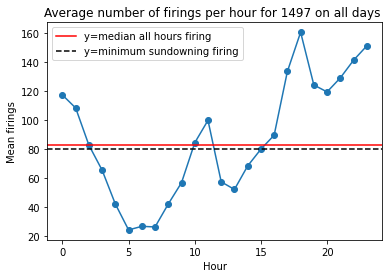

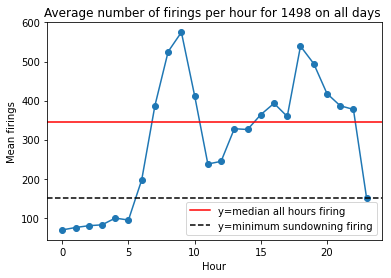

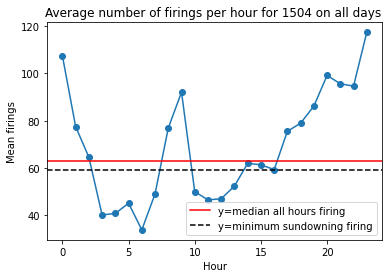

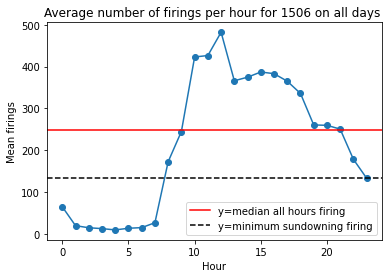

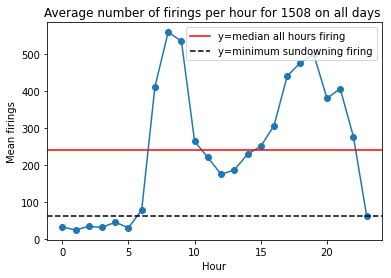

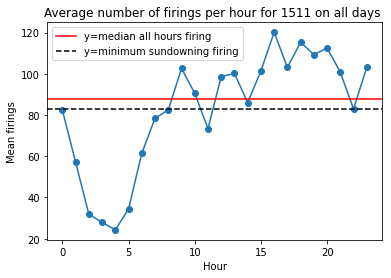

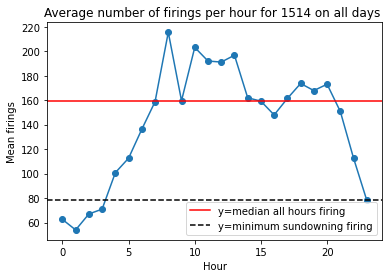

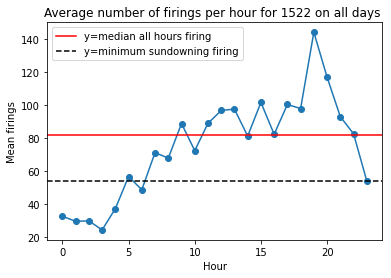

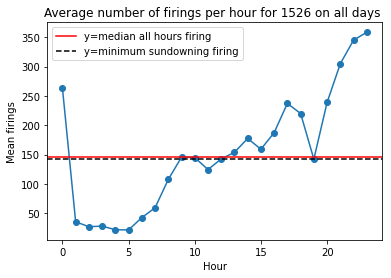

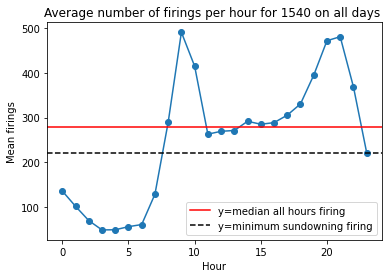

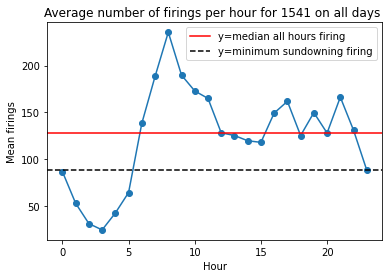

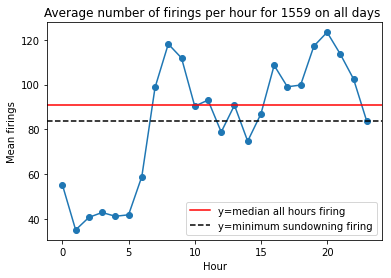

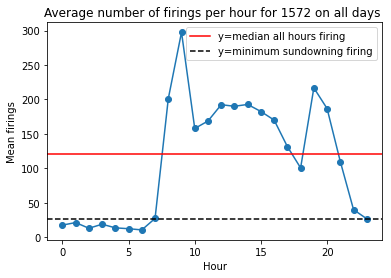

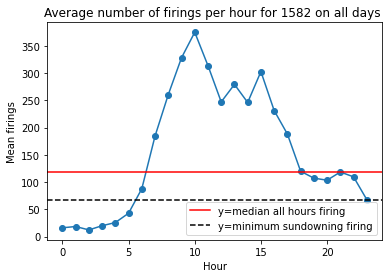

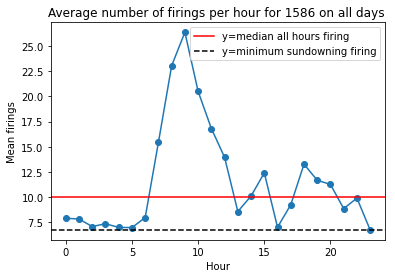

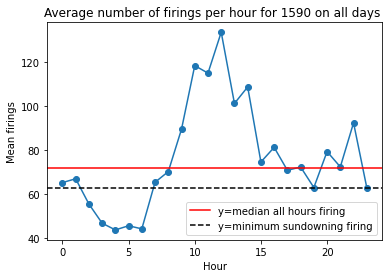

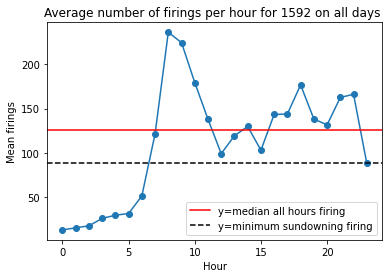

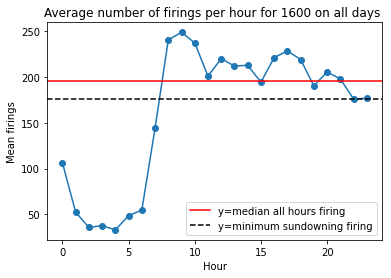

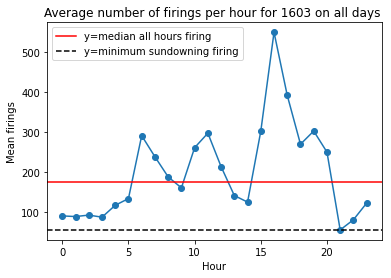

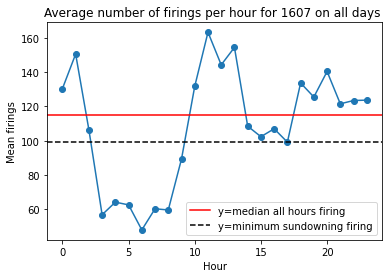

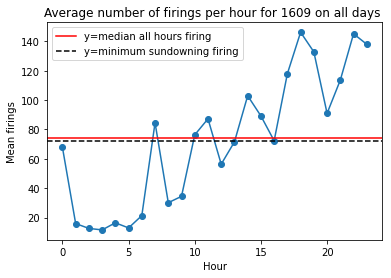

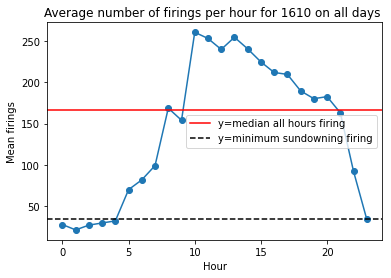

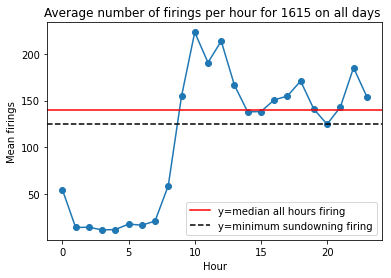

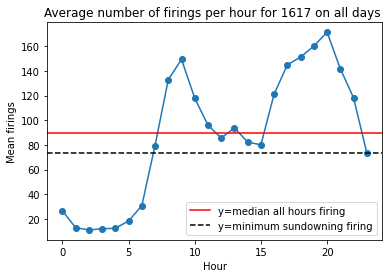

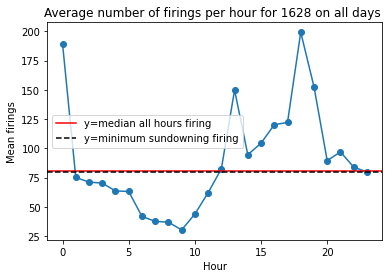

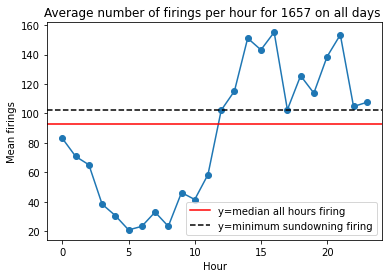

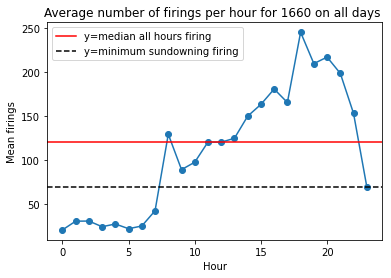

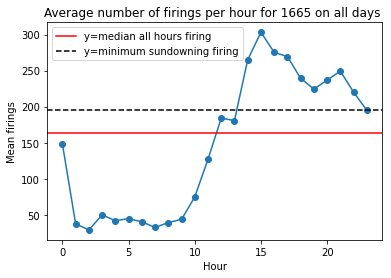

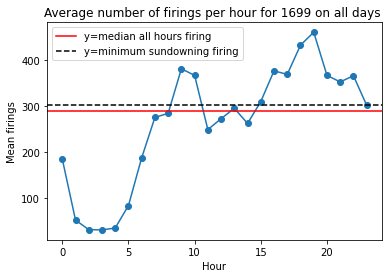

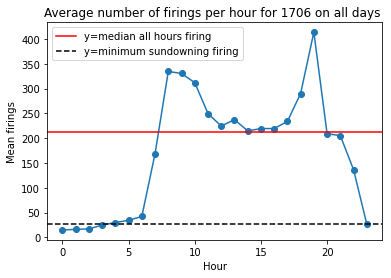

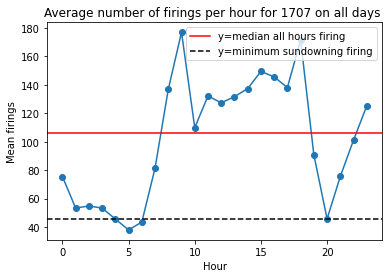

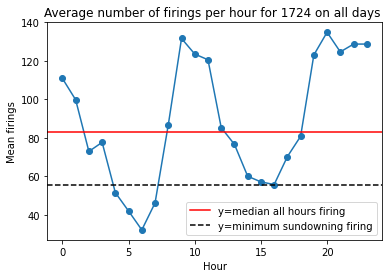

In [7]:
import statistics
for num in patients:
    #read data
    patient=num
    out = readData(patient)
    training_data= filter_training(patient,n_init=60)
    
    
#     left=read_left(patient,threhold)
#     visitor=[]
#     # visitor=readData_visitor(patient)
#     # Convert `left` and `visitor` lists to a set of (date, hour) tuples for easy lookup
#     left_set = {(datetime.strptime(date, '%d/%m/%Y').date(), hour) for date, hour, *_ in left}
#     visitor_set = {(datetime.strptime(date, '%d/%m/%Y').date(), hour) for date, hour in visitor}
#     cleaned_data=filter_data(training_data,visitor,left)
    
    
    firing_hour=count_firings(training_data)
    firing_data=hourly_firing(firing_hour)
    
    #    training for first n_init days
    data = firing_data

    hourly_mean = {}
    for hour, firings in data.items():
        # Filter out None values and zeroes
        filtered_firings = [firing for firing in firings if firing is not None and firing != 0]
        # Calculate mean if there are any firings left after filtering, otherwise set to 0
        if filtered_firings:
            hourly_mean[hour] = sum(filtered_firings) / len(filtered_firings)
        else:
            hourly_mean[hour] = 0
    # # Display the restructured data and mean
    # for i, (hour_data, mean) in enumerate(zip(hourly_data_filtered, hourly_mean)):
    #     print(f"Hour {i + 1}:", hour_data, "Mean:", mean)

    hours = list(hourly_mean.keys())
    mean_firings = list(hourly_mean.values())

    # Plot the hourly mean data
    plt.plot(hours, mean_firings, marker='o')
#     avg_firing=round(sum(hourly_mean.values()) / len(hourly_mean.values()))
#     expect=min(hourly_mean.values())+ (avg_firing-min(hourly_mean.values()))/2
    
    median_all=round(statistics.median(hourly_mean.values()))
    # Extract values for hours from 15 to 23 (sundowning)
    pm_values = {hour: value for hour, value in hourly_mean.items() if 15 <= hour <= 23}

    # Find the minimum value among the filtered hours
    min_value = min(pm_values.values())
    
    plt.axhline(y=median_all, color='red', linestyle='-', label='y=median all hours firing')  # Add a horizontal line at y=0.3
    plt.axhline(y=min_value, color='black', linestyle='--', label='y=minimum sundowning firing')  


    # Customize the plot
    plt.title(f"Average number of firings per hour for {patient} on all days ")
    plt.xlabel('Hour')
    plt.ylabel('Mean firings')
    plt.legend()

    # Show the plot
    plt.show()


In [8]:
#Nighttime---
Nighttime_1135=[0,1,2,3,4,5,6]
Nighttime_1450=[2,3,4,5]
Nighttime_1464=[0,1,2,3,4,5,6,7]
Nighttime_1497=[3,4,5,6,7,8,9] 
Nighttime_1498=[0,1,2,3,4,5]

Nighttime_1504=[3,4,5,6,7]
Nighttime_1506=[0,1,2,3,4,5,6,7]
Nighttime_1508=[0,1,2,3,4,5,6]
# Nighttime_1507=[1,2,3,4,5,6,7]
Nighttime_1511=[1,2,3,4,5,6,7]
Nighttime_1514=[0,1,2,3]

Nighttime_1522=[0,1,2,3,4,5,6]
Nighttime_1526=[1,2,3,4,5,6,7,8]
Nighttime_1540=[0,1,2,3,4,5,6,7]
Nighttime_1541=[1,2,3,4,5]
Nighttime_1559=[0,1,2,3,4,5,6]


# Nighttime_1571=[0,1,2,3,4,5]
Nighttime_1572=[0,1,2,3,4,5,6]
Nighttime_1582=[0,1,2,3,4,5]
Nighttime_1586=[0,1,2,3,4,5,6]#
Nighttime_1590=[2,3,4,5,6]
Nighttime_1592=[0,1,2,3,4,5,6]


Nighttime_1600=[0,1,2,3,4,5,6,7]
Nighttime_1603=[0,1,2,3,4,5]#
Nighttime_1607=[3,4,5,6,7,8,9]
Nighttime_1609=[1,2,3,4,5,6]#
Nighttime_1610=[0,1,2,3,4]

Nighttime_1615=[0,1,2,3,4,5,6,7,8]
Nighttime_1617=[0,1,2,3,4,5,6]
Nighttime_1628=[1,2,3,4,5,6,7,8,9,10,11,12]
Nighttime_1657=[0,1,2,3,4,5,6,7,8,9,10,11]#
Nighttime_1660=[0,1,2,3,4,5,6,7]


Nighttime_1665=[1,2,3,4,5,6,7,8,9,10]#
Nighttime_1699=[0,1,2,3,4,5,6]
Nighttime_1706=[0,1,2,3,4,5,6]#
Nighttime_1707=[0,1,2,3,4,5,6]#
Nighttime_1724=[4,5,6,7]


# Nighttime_1618=[2,3,4,5,6,7]
# Nighttime_1693=[2,3,4,5,6,7,8,9]##
# Nighttime_1627=[0,1,2,3,4,5,6,7]
# Nighttime_1542=[0,1,2,3,4,5]
# Nighttime_1591=[2,3,4,5,6,7]
# Nighttime_1754=[0,1,2,3,4,5,6,7,8,9]#

nighttimes=[Nighttime_1135,Nighttime_1450,Nighttime_1464,Nighttime_1497,Nighttime_1498,
            Nighttime_1504,Nighttime_1506,Nighttime_1508,Nighttime_1511,Nighttime_1514,
            Nighttime_1522,Nighttime_1526,Nighttime_1540,Nighttime_1541,Nighttime_1559,
            Nighttime_1572,Nighttime_1582,Nighttime_1586,Nighttime_1590,Nighttime_1592,
            Nighttime_1600,Nighttime_1603,Nighttime_1607,Nighttime_1609,Nighttime_1610,
            Nighttime_1615,Nighttime_1617,Nighttime_1628,Nighttime_1657,Nighttime_1660,
            Nighttime_1665,Nighttime_1699,Nighttime_1706,Nighttime_1707,Nighttime_1724]

In [9]:
# Initialize an empty dictionary to hold the results
nighttimes_dict = {}

# Make a copy of the list of keys in globals() to safely iterate
global_items = list(globals().items())

# Iterate over the copied list of global items
for key, value in global_items:
    # Check if the key starts with 'Nighttime_' and the value is a list
    if key.startswith('Nighttime_') and isinstance(value, list):
        # Extract the numeric part of the key
        numeric_part = int(key.split('_')[1])
        # Add to the nighttimes_dict
        nighttimes_dict[numeric_part] = value
nighttimes_dict

{1135: [0, 1, 2, 3, 4, 5, 6],
 1450: [2, 3, 4, 5],
 1464: [0, 1, 2, 3, 4, 5, 6, 7],
 1497: [3, 4, 5, 6, 7, 8, 9],
 1498: [0, 1, 2, 3, 4, 5],
 1504: [3, 4, 5, 6, 7],
 1506: [0, 1, 2, 3, 4, 5, 6, 7],
 1508: [0, 1, 2, 3, 4, 5, 6],
 1511: [1, 2, 3, 4, 5, 6, 7],
 1514: [0, 1, 2, 3],
 1522: [0, 1, 2, 3, 4, 5, 6],
 1526: [1, 2, 3, 4, 5, 6, 7, 8],
 1540: [0, 1, 2, 3, 4, 5, 6, 7],
 1541: [1, 2, 3, 4, 5],
 1559: [0, 1, 2, 3, 4, 5, 6],
 1572: [0, 1, 2, 3, 4, 5, 6],
 1582: [0, 1, 2, 3, 4, 5],
 1586: [0, 1, 2, 3, 4, 5, 6],
 1590: [2, 3, 4, 5, 6],
 1592: [0, 1, 2, 3, 4, 5, 6],
 1600: [0, 1, 2, 3, 4, 5, 6, 7],
 1603: [0, 1, 2, 3, 4, 5],
 1607: [3, 4, 5, 6, 7, 8, 9],
 1609: [1, 2, 3, 4, 5, 6],
 1610: [0, 1, 2, 3, 4],
 1615: [0, 1, 2, 3, 4, 5, 6, 7, 8],
 1617: [0, 1, 2, 3, 4, 5, 6],
 1628: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 1657: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 1660: [0, 1, 2, 3, 4, 5, 6, 7],
 1665: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 1699: [0, 1, 2, 3, 4, 5, 6],
 1706: [0, 1, 2, 3, 4, 5,

In [10]:
sundowning_hours_general=list(range(15,24))
sundowning_hours_general

sundowning_hours=[]
for each_night in nighttimes:
    # Start with the general sundowning hours
    sundown = list(sundowning_hours_general)
    
    # If the nighttime list does not start with 0, add the missing hours to sundowning_hours
    if each_night[0] != 0:
        sundown.extend(range(0, each_night[0]))
        
    # Remove any hours that are in the nighttime list
    sundown = [hour for hour in sundown if hour not in each_night]
    
    # Append the updated sundown list to sundowning_hours
    sundowning_hours.append(sundown)
    
    
hours=[i for i in range(0,24)]
# Calculate daytime hours for each user by removing nighttime and sundowning hours from the total hours
daytimes = []
for i in range(len(nighttimes)):
    # Combine nighttime and sundowning hours and remove duplicates
    excluded_hours = set(nighttimes[i] + sundowning_hours[i])
    # Calculate daytime hours by excluding the combined hours from the total hours
    daytime_hours = [hour for hour in hours if hour not in excluded_hours]
    daytimes.append(daytime_hours)

daytimes